<a href="https://colab.research.google.com/github/izDeLaMo/carisurg-portfolio/blob/main/W0Assignement3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CariSurg MedTech Pathways — Week 0, Assignment 3


## 1. Setup — Load and Clean

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Carisurg/Copy of EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


## Visualization

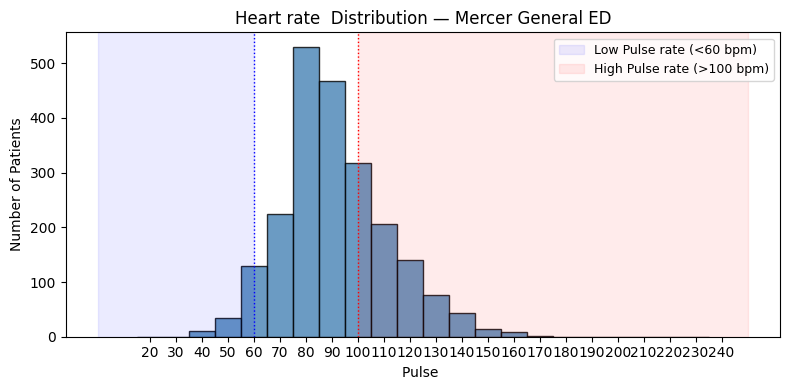

Saved: pulse_histogram.png


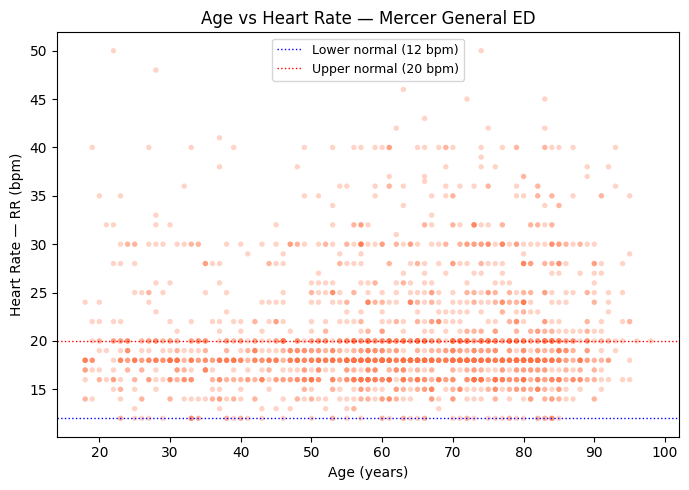

Saved: age_vs_RR.png


In [17]:
# ── YOUR TURN ────────────────────────────────────────────────
# Pick any two variables from the dataset and create a meaningful plot.
# Before you code, answer these questions in a comment:
#
# 1. What is the clinical question this plot answers?
# 2. What type of plot is appropriate (histogram, scatter, bar, box)?
# 3. What reference lines or annotations would add clinical meaning?

# Your code here:
# 1. Clinical question:
# Does the patient pulse distribution show abnormal heart rate ranges,
# and is there any relationship between patient age and respiratory rate (RR)?

# 2. Appropriate plots:
# Histogram for pulse distribution and scatter plot for Age vs RR relationship.

# 3. Clinical reference lines/annotations:
# Normal pulse range markers at 60 and 100 bpm,
# and normal respiratory rate markers at 12 and 20 bpm.

# Histogram: pulse distribution
fig, ax = plt.subplots(figsize=(8, 4))
bins=range(20, 250, 10)
ax.hist(df['pulse'], bins=bins, edgecolor='black',
        color='steelblue', alpha=0.8, align='left')



ax.axvspan(0, 60, alpha=0.08, color='blue', label='Low Pulse rate (<60 bpm)')
ax.axvspan(100, 250, alpha=0.08, color='red', label='High Pulse rate (>100 bpm)')
ax.axvline(x=60, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=100, color='red', linestyle=':', linewidth=1)

ax.set_title('Heart rate  Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Pulse ')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(20, 250, 10))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pulse_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: pulse_histogram.png")

# Scatter plot: Age vs RR — does age affect resting heart rate in ED patients?
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['Age'], df['RR'],
           alpha=0.3, s=15, color='#FF7043', edgecolors='none')

ax.set_title('Age vs Heart Rate — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Heart Rate — RR (bpm)')

# Add clinical reference lines
ax.axhline(y=12, color='blue', linestyle=':', linewidth=1, label='Lower normal (12 bpm)')
ax.axhline(y=20, color='red', linestyle=':', linewidth=1, label='Upper normal (20 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_RR.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: age_vs_RR.png")



# plt.savefig('my_plot.png', dpi=100, bbox_inches='tight')
# plt.show()